# Customer Analytics: Predicción de CLV y Segmentación de Clientes

## 📌 Descripción del proyecto

Este proyecto aborda dos problemas clave en analítica de clientes:

- **Predicción del Customer Lifetime Value (CLV)**: estimación del valor económico futuro de cada cliente mediante modelos de regresión.
- **Segmentación de clientes (RFM)**: identificación de grupos de clientes según su comportamiento.

Estas técnicas se utilizan en entornos reales de negocio para:
- Optimizar la inversión en marketing
- Mejorar la retención de clientes
- Personalizar la experiencia del cliente

---

## 📊 Datasets

- **CLV Dataset**: IBM Telco Marketing Customer Value Analysis  
- **Online Retail Dataset**: UCI Machine Learning Repository

---

## 🧰 Tecnologías utilizadas

- Python (Pandas, NumPy)
- Scikit-learn
- Matplotlib / Seaborn

## 1. Predicción del Customer Lifetime Value (CLV)

Comenzamos analizando un dataset de clientes para construir un modelo que estime el **Customer Lifetime Value (CLV)**.

El CLV permite estimar el valor económico que un cliente puede generar a lo largo del tiempo.

In [25]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [9]:
df_clv = pd.read_csv('data/clv/WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv', index_col=0)

print(f"Filas: {df_clv.shape[0]}")
print(f"Columnas: {df_clv.shape[1]}")

df_clv.head()

Filas: 9134
Columnas: 23


,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
Customer,,,,,,,,,,,,,,,,,,,,,
BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,Suburban,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,Suburban,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,Suburban,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,Suburban,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,Rural,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


## Clasificación de variables

Separamos las variables en:
- Variables numéricas
- Variables categóricas

In [10]:
num_df_columns = df_clv.select_dtypes(include=np.number).columns.to_list()
dis_df_columns = df_clv.select_dtypes(exclude=np.number).columns.to_list()

# quitamos target
num_df_columns.remove('Customer Lifetime Value')

## Ingeniería de variables temporales

Convertimos la columna `Effective To Date` en una variable numérica que representa el número de días desde la fecha más antigua del dataset.

In [11]:
df_clv['Effective To Date'] = pd.to_datetime(
    df_clv['Effective To Date'],
    format='mixed'   # <- clave para evitar el error
)

min_date = df_clv['Effective To Date'].min()
df_clv['Effective To Date'] = (df_clv['Effective To Date'] - min_date).dt.days

num_df_columns.append('Effective To Date')
dis_df_columns.remove('Effective To Date')

## Análisis de la variable objetivo

Analizamos la distribución del CLV.

Se observan valores extremos que, aunque reales, pueden afectar negativamente al modelo.  
Por ello, se filtran aproximadamente el 5% superior.

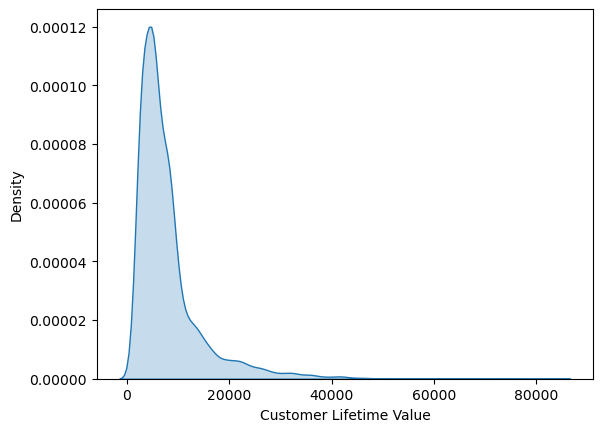

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_clv, x="Customer Lifetime Value", fill=True)
plt.show()

In [13]:
df_clv = df_clv[df_clv['Customer Lifetime Value'] < 22000]

### Pipelines de preprocesado

In [14]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [15]:
clv_trans = ColumnTransformer(transformers=[
    ('num', num_transformer, num_df_columns),
    ('cat', cat_transformer, dis_df_columns)
])

## División de datos

In [16]:
X = df_clv[df_clv['Customer Lifetime Value'] < 22000].drop('Customer Lifetime Value', axis=1)
y = df_clv[df_clv['Customer Lifetime Value'] < 22000]['Customer Lifetime Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=0
)

## Preprocesamiento de datos

Se aplican:
- Escalado a variables numéricas
- Codificación a variables categóricas

## Modelo base: Regresión Lineal

Se utiliza un modelo simple como baseline.

In [17]:
pipe_lin = Pipeline([
    ('prep', clv_trans),
    ('model', LinearRegression())
])

pipe_lin.fit(X_train, y_train)

print("R2 Train:", pipe_lin.score(X_train, y_train))
print("R2 Test:", pipe_lin.score(X_test, y_test))

R2 Train: 0.20364829619665548
R2 Test: 0.20095626562618862


## Evaluación del modelo

Se utilizan:
- Error absoluto medio (MAE)
- Error relativo medio

In [18]:
from sklearn.metrics import mean_absolute_error

def show_errors(y, y_pred):
    mae = mean_absolute_error(y, y_pred)
    rmae = np.mean(np.abs((y - y_pred) / y))
    
    print(f"MAE: {mae:.2f}")
    print(f"Error relativo: {rmae:.2f}")

## Modelo mejorado: Árbol de decisión

Se introduce un modelo no lineal para capturar relaciones más complejas.

In [19]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

pipe_tree = Pipeline([
    ('prep', clv_trans),
    ('model', tree)
])

pipe_tree.fit(X_train, y_train)

print("Train:", pipe_tree.score(X_train, y_train))
print("Test:", pipe_tree.score(X_test, y_test))

Train: 1.0
Test: 0.6818870355330033


## Optimización de hiperparámetros

Se ajusta la profundidad del árbol para reducir el sobreajuste.

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [2, 5, 10, 15, 20]
}

grid = GridSearchCV(
    pipe_tree,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Mejores parámetros:", grid.best_params_)
print("R2 Test:", best_model.score(X_test, y_test))

Mejores parámetros: {'model__max_depth': 10}
R2 Test: 0.7815436760147149


## 2. Segmentación de clientes (RFM)

Se segmentan los clientes en función de:
- Recency (recencia)
- Frequency (frecuencia)
- Monetary Value (valor monetario)

Este enfoque permite identificar distintos perfiles de clientes.

In [30]:
df_ol = pd.read_csv(
    'data/segmentation/online12M.csv',
    index_col=0,
    parse_dates=['InvoiceDate']
)

df_ol.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
416792,572558,22745,POPPY'S PLAYHOUSE BEDROOM,6,2011-10-25,2.10,14286,United Kingdom
482904,577485,23196,VINTAGE LEAF MAGNETIC NOTEPAD,1,2011-11-20,1.45,16360,United Kingdom
263743,560034,23299,FOOD COVER WITH BEADS SET 2,6,2011-07-14,3.75,13933,United Kingdom
495549,578307,72349B,SET/6 PURPLE BUTTERFLY T-LIGHTS,1,2011-11-23,2.10,17290,United Kingdom
204384,554656,21756,BATH BUILDING BLOCK WORD,3,2011-05-25,5.95,17663,United Kingdom


## Construcción de variables RFM

In [31]:
df_ol['Total'] = df_ol['Quantity'] * df_ol['UnitPrice']
df_ol.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
416792,572558,22745,POPPY'S PLAYHOUSE BEDROOM,6,2011-10-25,2.10,14286,United Kingdom,12.60
482904,577485,23196,VINTAGE LEAF MAGNETIC NOTEPAD,1,2011-11-20,1.45,16360,United Kingdom,1.45
263743,560034,23299,FOOD COVER WITH BEADS SET 2,6,2011-07-14,3.75,13933,United Kingdom,22.50
495549,578307,72349B,SET/6 PURPLE BUTTERFLY T-LIGHTS,1,2011-11-23,2.10,17290,United Kingdom,2.10
204384,554656,21756,BATH BUILDING BLOCK WORD,3,2011-05-25,5.95,17663,United Kingdom,17.85


In [32]:
import datetime
reference_date = df_ol['InvoiceDate'].max() + datetime.timedelta(days=1)

df_rfm = df_ol.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'count',
    'Total': 'sum'
})

df_rfm.columns = ['Recency', 'Frequency', 'MonetaryValue']
df_rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12747,3,25,948.70
12748,1,888,7046.16
12749,4,37,813.45
12820,4,17,268.02
12822,71,9,146.15


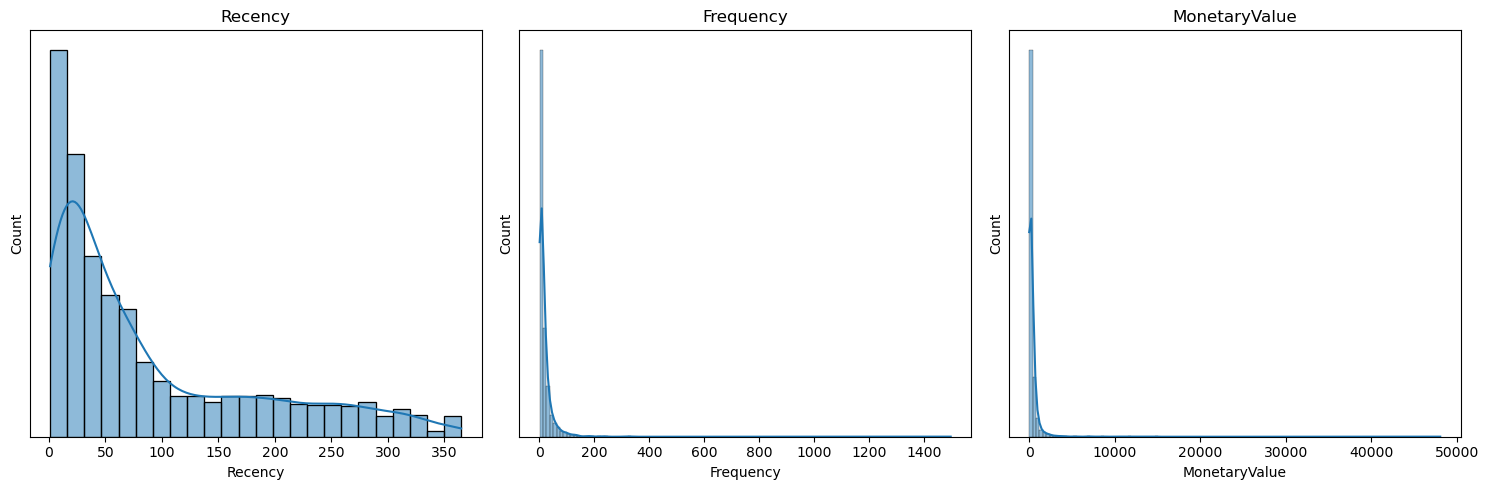

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
features = ['Recency', 'Frequency', 'MonetaryValue']

for col, ax in enumerate(axs.flatten()):
    col_name = features[col]
    
    sns.histplot(df_rfm[col_name], kde=True, ax=ax)
    
    ax.set_title(col_name, fontsize=12)
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Normalización de datos

Se aplica:
- Transformación logarítmica
- Estandarización

In [35]:
df_rfm_log = np.log(df_rfm)

df_rfm_norm = (df_rfm_log - df_rfm_log.mean()) / df_rfm_log.std()
df_rfm_norm.describe()

,Recency,Frequency,MonetaryValue
count,3.643000e+03,3.643000e+03,3.643000e+03
mean,-7.704210e-17,2.164981e-16,3.627805e-16
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.814131e+00,-1.794485e+00,-4.092988e+00
25%,-6.373074e-01,-6.490904e-01,-6.578277e-01
50%,9.266763e-02,2.092218e-02,-1.489601e-02
75%,8.339256e-01,7.209827e-01,6.692029e-01
max,1.547663e+00,4.246243e+00,4.458854e+00


## Clustering con K-Means

Se utiliza el método del codo para determinar el número óptimo de clusters.

In [26]:
from sklearn.cluster import KMeans

cost = {}
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_rfm_norm)
    cost[k] = kmeans.inertia_

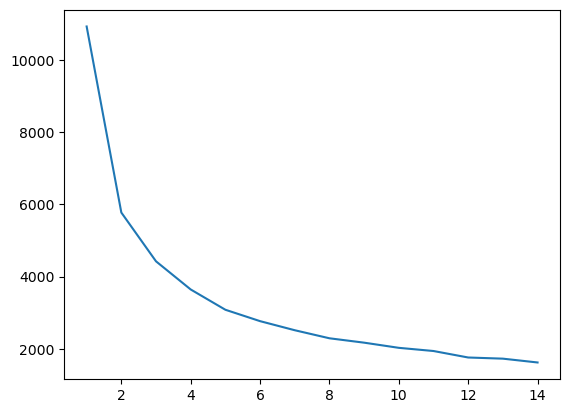

In [36]:
plt.plot(cost.keys(),cost.values()); 

## Segmentación final (k=4)

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_rfm['Cluster'] = kmeans.fit_predict(df_rfm_norm)

## Interpretación de clusters

Se analiza la importancia relativa de cada variable por grupo.

In [28]:
cluster_means = df_rfm.groupby('Cluster').mean()

relative_imp = cluster_means.divide(df_rfm.mean()) - 1

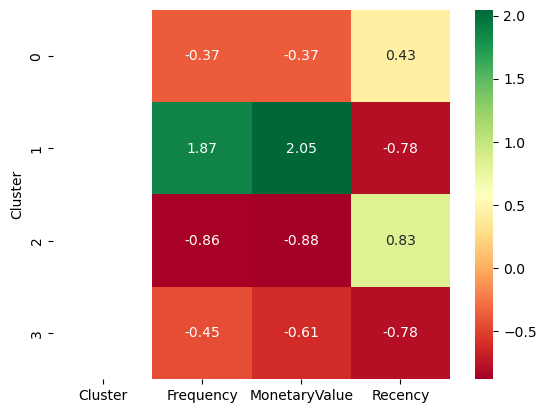

In [29]:
import seaborn as sns

sns.heatmap(relative_imp, annot=True, fmt=".2f", cmap="RdYlGn")
plt.show()

## 📌 Conclusiones

- Los modelos lineales presentan baja capacidad explicativa en CLV
- Los modelos basados en árboles mejoran significativamente el rendimiento
- La segmentación permite identificar perfiles diferenciados de clientes:
  - Clientes de alto valor
  - Clientes inactivos
  - Clientes frecuentes de bajo gasto

---

## 🚀 Próximos pasos

- Probar modelos más avanzados (Random Forest, XGBoost)
- Aplicar la segmentación en estrategias de marketing
- Construir modelos de clasificación de valor de cliente